In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from qpsolvers import solve_qp
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay
from lab_2 import plot_quadratic_boundary
from sklearn.preprocessing import StandardScaler
from lab_2 import experimental_probability_error

Первая часть

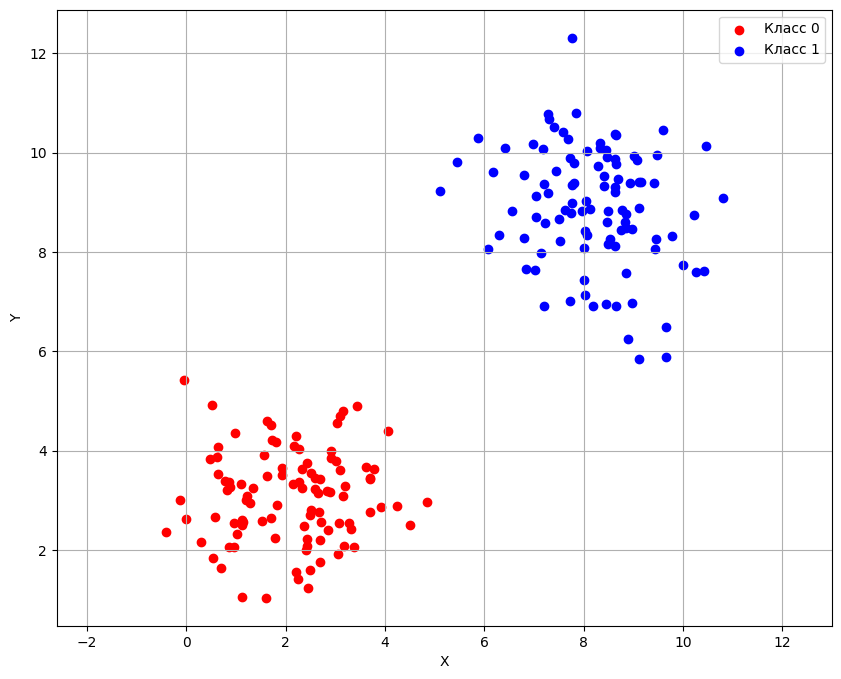

In [15]:
def generate_random_vectors(M, B, N, file_name):
    A = np.zeros((2,2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[1, 0] / A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - (B[1, 0]**2 / B[0, 0]))
    
    E = np.random.randn(2, N)

    X = np.dot(A, E) + M
    np.save(file_name, X)


N = 100

M_0 = np.array([[2] ,[3]])
B_0 = np.array([[1.5, 0.0], [0.0, 1.0]])

M_1 = np.array([[8], [9]]) 
B_1 = np.array([[1.2, -0.2], [-0.2, 1.3]])

path_to_first_file = 'sample_1.npy'
path_to_second_file = 'sample_2.npy'

generate_random_vectors(M_0, B_0, N, path_to_first_file)
generate_random_vectors(M_1, B_1, N, path_to_second_file)

X0 = np.load(path_to_first_file)
X1 = np.load(path_to_second_file)

plt.figure(figsize=(10, 8))
plt.scatter(X0[0, :], X0[1, :], color='red', label='Класс 0')
plt.scatter(X1[0, :], X1[1, :], color='blue', label='Класс 1')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Вторая часть. Построить линейный классификатор по методу опорных
векторов на выборке с линейно разделимыми классами. 

In [ ]:
def build_svm_linear_separable(X0, X1):
    x = np.hstack([X0, X1]).T
    r = np.hstack([-np.ones(X0.shape[1]), np.ones(X1.shape[1])])
    N = len(r)
    
    P = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            P[i, j] = r[i] * r[j] * np.dot(x[i], x[j])
    
    q = -np.ones(N) 
    
    A = r.reshape(1, -1)
    b = np.array([0.0])
    
    G = -np.eye(N)
    h = np.zeros(N)
    
    lambdas = solve_qp(P, q, G, h, A, b, solver='cvxopt')
    
    idx = lambdas > 1e-3
    support_vectors = x[idx]
    r_sv = r[idx]
    support_lambda = lambdas[idx]
    
    print(f"Найдено опорных векторов: {len(support_vectors)}")
    
    w = np.zeros(2)
    for i in range(len(support_vectors)):
        w += support_lambda[i] * r_sv[i] * support_vectors[i]

    wn = r_sv[0] - np.dot(w, support_vectors[0])
    
    return w, wn, support_vectors, r_sv, x, r


print("A) Решение методом квадратичных задач:")
w, wn, support_vectors, r_sv, x, r = build_svm_linear_separable(X0, X1)

A) Решение методом квадратичных задач:
Найдено опорных векторов: 3


In [68]:
print('Б) Обучение SVC с линейным ядром:\n')
svc = SVC(kernel='linear')
svc.fit(x, r)

print("Параметры SVC:")
print(f"Веса: {svc.coef_[0]}")
print(f"Порог: {svc.intercept_[0]}")

Б) Обучение SVC с линейным ядром:

Параметры SVC:
Веса: [0.35286178 0.35287362]
Порог: -3.984624728386587


In [ ]:
print('В) LinearSVC')
linear_svc = LinearSVC(dual='auto')

# linear_svc = LinearSVC(
#     C=1000000,    
#     loss='hinge',
#     max_iter=100000,
#     dual='auto'
#)

linear_svc.fit(x, r)

print("Параметры LinearSVC:")
print(f"Веса: {linear_svc.coef_[0]}")
print(f"Порог: {linear_svc.intercept_[0]}")

В) LinearSVC
Параметры LinearSVC:
Веса: [0.22834374 0.23726421]
Порог: -2.5488808010610944


In [67]:
def find_support_vectors_sklearn(clf, X, tolerance=1e-5):
    decision_values = clf.decision_function(X)
    
    margin = np.abs(np.abs(decision_values) - 1) < tolerance
    violators = np.abs(decision_values) < 1 + tolerance
    
    support_mask = margin | violators
    support_vectors = X[support_mask]
    
    return support_vectors


In [20]:
def create_bayes_classifier(ax, X0, X1, M0, M1, B0, B1, color = None):
    all_data = np.hstack([X0, X1])
    x_min, x_max = np.min(all_data[0, :]), np.max(all_data[0, :])
    y_min, y_max = np.min(all_data[1, :]), np.max(all_data[1, :])
    if color == None:
        color = 'black'
    plot_quadratic_boundary(M0, M1, B0, B1, ax, color, 'Граница Байеса', (x_min, x_max), (y_min, y_max), 0.5, 0.5)

<Figure size 1500x500 with 0 Axes>

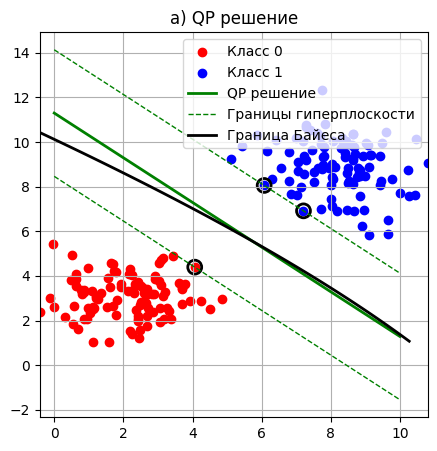

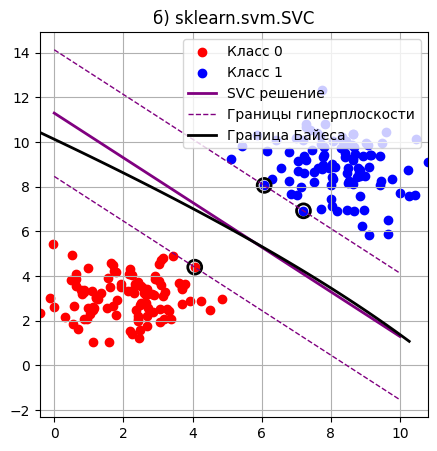

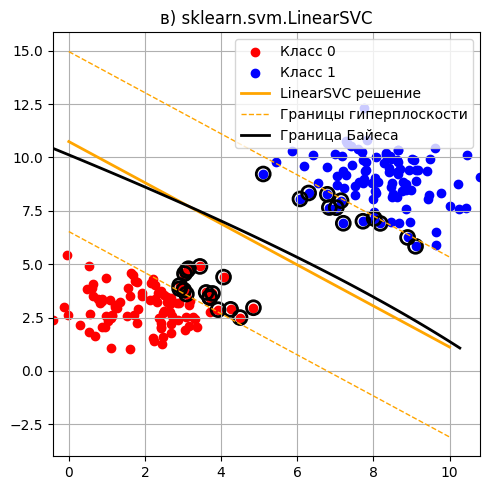

In [ ]:
support_vectors_lsvc = find_support_vectors_sklearn(linear_svc, x, tolerance=1e-3)
support_vectors_svc = find_support_vectors_sklearn(svc, x, tolerance=1e-3)

plt.figure(figsize=(15, 5))
x_plot = np.linspace(0, 10, 100)

# 1. QP решение
#ax.subplot(1, 3, 1)
_ , ax = plt.subplots(figsize=(5, 5))
ax.scatter(X0[0, :], X0[1, :], c='red', label='Класс 0')
ax.scatter(X1[0, :], X1[1, :], c='blue', label='Класс 1')

ax.scatter([sv[0] for sv in support_vectors], [sv[1] for sv in support_vectors],
           facecolors='none', edgecolors='black', s=100, linewidth=2,)

y_qp = (-w[0] * x_plot - wn) / w[1]
ax.plot(x_plot, y_qp, 'g-', linewidth=2, label='QP решение')

y_margin_upper_qp = (-w[0] * x_plot - wn + 1) / w[1]
y_margin_lower_qp = (-w[0] * x_plot - wn - 1) / w[1]

ax.plot(x_plot, y_margin_upper_qp, 'g--', linewidth=1, label='Границы гиперплоскости')
ax.plot(x_plot, y_margin_lower_qp, 'g--', linewidth=1)

create_bayes_classifier(ax, X0, X1, M_0, M_1, B_0, B_1)

ax.set_title('а) QP решение')
ax.grid(True)
ax.legend()

# 2. SVC решение
_ , ax = plt.subplots(figsize=(5, 5))
# plt.subplot(1, 3, 2)
ax.scatter(X0[0, :], X0[1, :], c='red', label='Класс 0')
ax.scatter(X1[0, :], X1[1, :], c='blue', label='Класс 1')

ax.scatter(support_vectors_svc[:, 0], support_vectors_svc[:, 1], facecolors='none', edgecolors='black', s=100, linewidth=2)

y_svc = (-svc.coef_[0][0] * x_plot - svc.intercept_[0]) / svc.coef_[0][1]
ax.plot(x_plot, y_svc, 'purple', linewidth=2, label='SVC решение')

y_margin_upper_svc = (-svc.coef_[0][0] * x_plot - svc.intercept_[0] + 1) / svc.coef_[0][1]
y_margin_lower_svc = (-svc.coef_[0][0] * x_plot - svc.intercept_[0] - 1) / svc.coef_[0][1]

ax.plot(x_plot, y_margin_upper_svc, 'purple', linestyle='--', linewidth=1, label='Границы гиперплоскости')
ax.plot(x_plot, y_margin_lower_svc, 'purple', linestyle='--', linewidth=1)

create_bayes_classifier(ax, X0, X1, M_0, M_1, B_0, B_1)

ax.set_title('б) sklearn.svm.SVC')
ax.grid(True)
ax.legend()

# 3. LinearSVC решение
_ , ax = plt.subplots(figsize=(5, 5))
ax.scatter(X0[0, :], X0[1, :], c='red', label='Класс 0')
ax.scatter(X1[0, :], X1[1, :], c='blue', label='Класс 1')

y_linear_svc = (-linear_svc.coef_[0][0] * x_plot - linear_svc.intercept_[0]) / linear_svc.coef_[0][1]
ax.plot(x_plot, y_linear_svc, 'orange', linewidth=2, label='LinearSVC решение')

y_margin_upper_lsvc = (-linear_svc.coef_[0][0] * x_plot - linear_svc.intercept_[0] + 1) / linear_svc.coef_[0][1]
y_margin_lower_lsvc = (-linear_svc.coef_[0][0] * x_plot - linear_svc.intercept_[0] - 1) / linear_svc.coef_[0][1]

ax.plot(x_plot, y_margin_upper_lsvc, 'orange', linestyle='--', linewidth=1, label='Границы гиперплоскости')
ax.plot(x_plot, y_margin_lower_lsvc, 'orange', linestyle='--', linewidth=1,)

ax.scatter(support_vectors_lsvc[:, 0], support_vectors_lsvc[:, 1], facecolors='none', edgecolors='black', s=100, linewidth=2)

create_bayes_classifier(ax, X0, X1, M_0, M_1, B_0, B_1)

ax.set_title('в) sklearn.svm.LinearSVC')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [27]:
def calculate_errors(W, wN, X, r):
    if X.shape[0] == 2:
        X = X.T
    
    if W.ndim == 2 and W.shape[1] == 1:
        W = W.flatten()
    
    d = X @ W + wN
    
    error_01 = np.sum((r == -1) & (d > 0))
     
    error_10 = np.sum((r == 1) & (d < 0))

    n_class0 = np.sum(r == -1)
    n_class1 = np.sum(r == 1)
    
    p0 = error_01 / n_class0 if n_class0 > 0 else 0
    p1 = error_10 / n_class1 if n_class1 > 0 else 0
    
    return p0, p1

error_01_qp, error_10_qp = calculate_errors(w, wn, x, r)

print("1.QP РЕШЕНИЕ:")
print(f"Ошибка первого рода: {error_01_qp}")
print(f"Ошибка второго рода : {error_10_qp}\n")

error_01_svc, error_10_svc = calculate_errors(svc.coef_[0], svc.intercept_[0], x, r)

print("2. SVC (sklearn):")
print(f"Ошибка первого рода: {error_01_svc}")
print(f"Ошибка второго рода: {error_10_svc}\n")

error_01_lsvc, error_10_lsvc = calculate_errors(linear_svc.coef_[0], linear_svc.intercept_[0], x, r)

print("3. LinearSVC (sklearn):")
print(f"Ошибка первого рода: {error_01_lsvc}")
print(f"Ошибка второго рода: {error_10_lsvc}")

1.QP РЕШЕНИЕ:
Ошибка первого рода: 0.0
Ошибка второго рода : 0.0

2. SVC (sklearn):
Ошибка первого рода: 0.0
Ошибка второго рода: 0.0

3. LinearSVC (sklearn):
Ошибка первого рода: 0.0
Ошибка второго рода: 0.0


3. Построить линейный классификатор по методу опорных
векторов на выборке с линейно неразделимыми классами. 

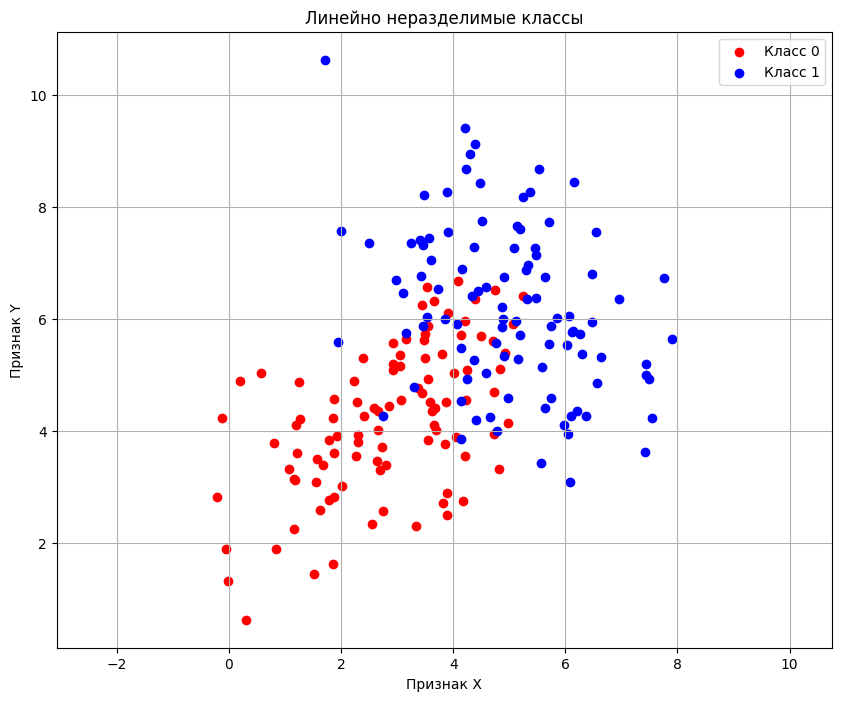

In [28]:
M0 = np.array([[3], [4]])
M1 = np.array([[5], [6]])

B0 = np.array([[2.0, 1.2], [1.2, 1.8]])
B1 = np.array([[1.8, -0.8], [-0.8, 2.2]])

N = 100

generate_random_vectors(M0, B0, N, 'sample2_class0.npy')
generate_random_vectors(M1, B1, N, 'sample2_class1.npy')

X_0 = np.load('sample2_class0.npy')
X_1 = np.load('sample2_class1.npy')

plt.figure(figsize=(10, 8))

plt.scatter(X_0[0, :], X_0[1, :], color='red', label='Класс 0')
plt.scatter(X_1[0, :], X_1[1, :], color='blue', label='Класс 1')

plt.xlabel('Признак X')
plt.ylabel('Признак Y')
plt.title('Линейно неразделимые классы')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [ ]:
def build_svm_with_C(X0, X1, C, tolerance=1e-3):
    x = np.hstack([X0, X1]).T
    r = np.hstack([-np.ones(X0.shape[1]), np.ones(X1.shape[1])])
    N = len(r)
    
    P = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            P[i, j] = r[i] * r[j] * np.dot(x[i], x[j])
    
    q = -np.ones(N)
    A = r.reshape(1, -1)
    b = np.array([0.0])
    
    G = np.vstack([-np.eye(N), np.eye(N)])
    h = np.hstack([np.zeros(N), np.ones(N) * C])

    lambdas = solve_qp(P, q, G, h, A, b, solver='cvxopt')

    margin_mask = (lambdas > tolerance) & (lambdas < C - tolerance)
    margin_vectors = x[margin_mask]
    margin_labels = r[margin_mask]
    margin_lambdas = lambdas[margin_mask]

    support_mask = lambdas > tolerance
    support_vectors = x[support_mask]
    support_labels = r[support_mask]
    support_lambdas = lambdas[support_mask]
    
    w = np.zeros(2)
    for i in range(N):
        w += lambdas[i] * r[i] * x[i]
    
    wn_candidates = []
    for i in range(len(margin_vectors)):
        wn_candidate = margin_labels[i] - np.dot(w, margin_vectors[i])
        wn_candidates.append(wn_candidate)
    wn = np.mean(wn_candidates)
    
    return w, wn, support_vectors, support_labels, x, r, lambdas

In [35]:
def filter_support_vectors(w, wn, vectors, labels):
    filtered_vectors = []
    tolerance=1e-3
    for vec, label in zip(vectors, labels):
        decision_value = np.dot(w, vec) + wn
        if abs(decision_value) <= 1 + tolerance:
            filtered_vectors.append(vec)
    
    return np.array(filtered_vectors)

In [70]:
all_results = {}

for C in [0.1, 1.0, 10.0]:
    print(f"\nПри C равном {C}")
        
    results_C = {}
        
    print("1. QP РЕАЛИЗАЦИЯ:")
    w_qp, wn_qp, sv_qp, labels_qp, x_non, r, lambdas = build_svm_with_C(X_0, X_1, C)
    if w_qp is not None:
        p0_qp, p1_qp = calculate_errors(w_qp, wn_qp, x_non, r)
        results_C['qp'] = {
                'w': w_qp, 'wn': wn_qp, 'support_vectors': sv_qp, 'support_labels': labels_qp,
                'p0': p0_qp, 'p1': p1_qp
        }
        print(f"Ошибки: p0={p0_qp}, p1={p1_qp}")

    print("\n2. SVC (sklearn):")
    svc = SVC(kernel='linear', C=C)
    svc.fit(x_non, r)
    
    sv_svc = find_support_vectors_sklearn(svc, x_non, tolerance=1e-3)

    p0_svc, p1_svc = calculate_errors(svc.coef_[0], svc.intercept_[0], x_non, r)
    results_C['svc'] = {
            'w': svc.coef_[0], 'wn': svc.intercept_[0], 
            'support_vectors': sv_svc,
            'p0': p0_svc, 'p1': p1_svc,
            'model': svc
    }
    print(f"Ошибки: p0={p0_svc}, p1={p1_svc}")
        
    all_results[C] = results_C


При C равном 0.1
1. QP РЕАЛИЗАЦИЯ:
Ошибки: p0=0.17, p1=0.14

2. SVC (sklearn):
Ошибки: p0=0.17, p1=0.14

При C равном 1.0
1. QP РЕАЛИЗАЦИЯ:
Ошибки: p0=0.17, p1=0.13

2. SVC (sklearn):
Ошибки: p0=0.17, p1=0.13

При C равном 10.0
1. QP РЕАЛИЗАЦИЯ:
Ошибки: p0=0.17, p1=0.13

2. SVC (sklearn):
Ошибки: p0=0.17, p1=0.13


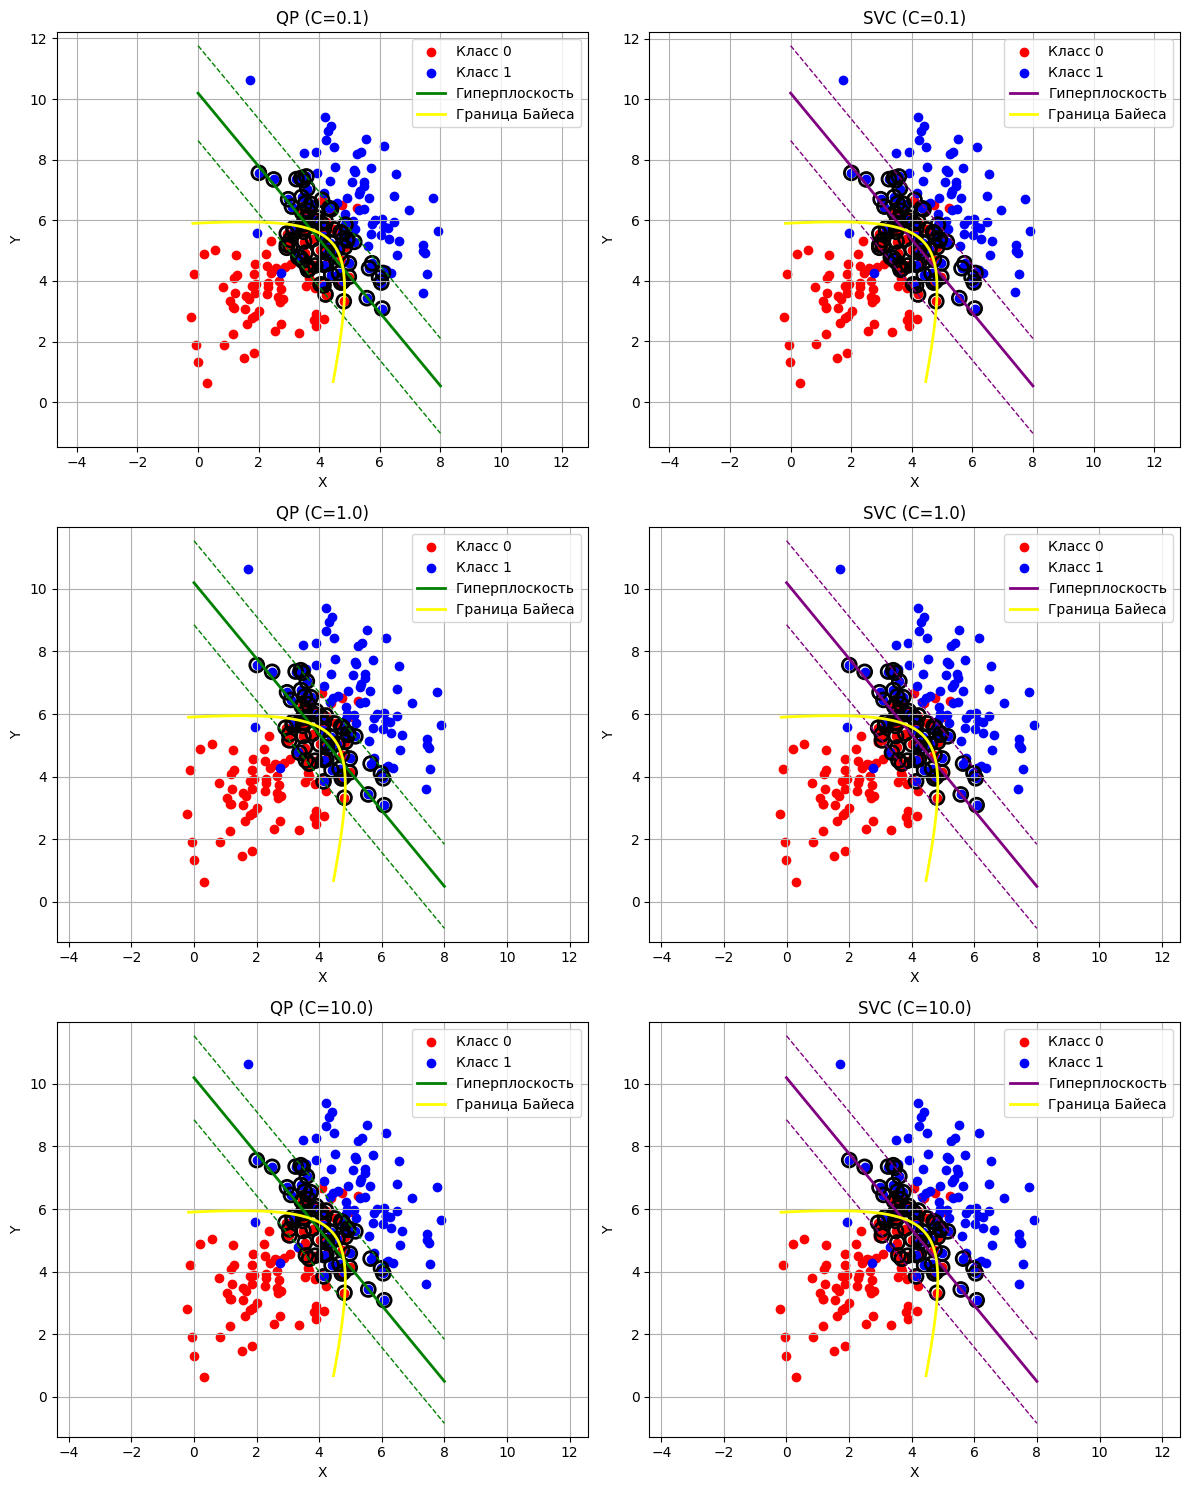

In [37]:
def visualize_qp_svc_comparison(all_results, X0, X1):
    C_values = list(all_results.keys())
    methods = ['qp', 'svc']
    method_names = ['QP', 'SVC']
    colors = ['green', 'purple']
    
    _, axes = plt.subplots(len(C_values), len(methods), figsize=(12, 15))
    
    for i, C in enumerate(C_values):
        for j, method in enumerate(methods):
            ax = axes[i, j] if len(C_values) > 1 else axes[j]
            results = all_results[C].get(method)
            
            w, wn = results['w'], results['wn']
            support_vectors = results['support_vectors']
            
            ax.scatter(X0[0, :], X0[1, :], c='red', label='Класс 0')
            ax.scatter(X1[0, :], X1[1, :], c='blue', label='Класс 1')
            
            if method == 'qp':
                support_labels = results['support_labels']
                support_vectors = filter_support_vectors(w, wn, support_vectors, support_labels)
            ax.scatter(support_vectors[:, 0], support_vectors[:, 1],
                facecolors='none', edgecolors='black', linewidth=2, s=100)
            
            x_plot = np.linspace(0, 8, 100)
            y_decision = (-w[0] * x_plot - wn) / w[1]
            ax.plot(x_plot, y_decision, color=colors[j], linewidth=2, label='Гиперплоскость')
            
            y_margin_upper = (-w[0] * x_plot - wn + 1) / w[1]
            y_margin_lower = (-w[0] * x_plot - wn - 1) / w[1]
            ax.plot(x_plot, y_margin_upper, color=colors[j], linestyle='--', linewidth=1)
            ax.plot(x_plot, y_margin_lower, color=colors[j], linestyle='--', linewidth=1)

            create_bayes_classifier(ax, X_0, X_1, M0, M1, B0, B1, color = 'yellow')
            
            ax.set_title(f'{method_names[j]} (C={C})')
            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.grid(True)
            ax.legend()
            ax.axis('equal')
    
    plt.tight_layout()
    plt.show()

visualize_qp_svc_comparison(all_results, X_0, X_1)

4. Построить линейный классификатор по методу опорных
векторов на выборке с линейно неразделимыми классами. 

In [43]:
def compute_kernel(x1, x2, kernel_type, params):
    if kernel_type == 'linear':
        return np.dot(x1, x2)
    
    elif kernel_type == 'poly_homogeneous':
        degree = params.get('degree', 2)
        return (np.dot(x1, x2)) ** degree
    
    elif kernel_type == 'poly_nonhomogeneous':
        degree = params.get('degree', 2)
        return (np.dot(x1, x2) + 1) ** degree
    
    elif kernel_type == 'rbf':
        gamma = params.get('gamma', 0.1)
        return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)
    
    elif kernel_type == 'gaussian_rbf':
        sigma = params.get('sigma', 1.0)
        gamma = 1.0 / (2 * sigma ** 2)
        return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)
    
    elif kernel_type == 'sigmoid':
        gamma = params.get('gamma', 0.1)
        c = params.get('c', 0)
        return np.tanh(gamma * np.dot(x1, x2) + c)
    
    else:
        raise ValueError(f"Неизвестный тип ядра: {kernel_type}")

In [44]:
def compute_kernel_matrix(X, kernel_type, params):
    N = X.shape[0]
    K = np.zeros((N, N))
    
    for i in range(N):
        for j in range(N):
            K[i, j] = compute_kernel(X[i], X[j], kernel_type, params)
    
    return K

In [45]:
def get_default_kernel_params(kernel_type):

    defaults = {
        'linear': {},
        'poly_homogeneous': {'degree': 2},
        'poly_nonhomogeneous': {'degree': 2},
        'rbf': {'gamma': 0.1},
        'gaussian_rbf': {'sigma': 1.0},
        'sigmoid': {'gamma': 0.1, 'c': 0}
    }
    return defaults.get(kernel_type, {})

In [61]:
def compute_bias(X, r, lambdas, K, C, kernel_type, kernel_params):
    margin_mask = (lambdas > 1e-3) & (lambdas < C - 1e-3)
    
    if not np.any(margin_mask):
        margin_mask = (lambdas > 1e-3)
    
    if not np.any(margin_mask):
        return 0.0
    
    margin_vectors = X[margin_mask]
    margin_labels = r[margin_mask]
    
    bias_candidates = []
    
    for i in range(len(margin_vectors)):
        kernel_sum = 0
        for j in range(len(X)):
            if lambdas[j] > 1e-3:
                kernel_val = compute_kernel(X[j], margin_vectors[i], kernel_type, kernel_params)
                kernel_sum += lambdas[j] * r[j] * kernel_val
        
        bias_i = margin_labels[i] - kernel_sum
        bias_candidates.append(bias_i)
    
    w_N = np.mean(bias_candidates)
    
    return w_N

In [62]:
def build_kernel_svm(X0, X1, C, kernel_type='rbf', kernel_params=None):
    x0 = X0.T
    x1 = X1.T
    
    x = np.vstack([x0, x1])
    r = np.hstack([-np.ones(len(x0)), np.ones(len(x1))])
    
    N = len(r)
    
    if kernel_params is None:
        kernel_params = get_default_kernel_params(kernel_type)
    
    K = compute_kernel_matrix(x, kernel_type, kernel_params)
    
    P = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i < K.shape[0] and j < K.shape[1]:
                P[i, j] = r[i] * r[j] * K[i, j]
            else:
                return None
    
    q = -np.ones(N)
    A = r.reshape(1, -1)
    b = np.array([0.0])
    
    G = np.vstack([-np.eye(N), np.eye(N)])
    h = np.hstack([np.zeros(N), np.ones(N) * C])
    
    try:
        lambdas = solve_qp(P, q, G, h, A, b, solver='cvxopt')
        print("QP решение найдено")
    except Exception as e:
        print(f"Ошибка QP: {e}")
        return None
    
    support_mask = (lambdas > 1e-3)
    support_vectors = x[support_mask]
    support_labels = r[support_mask]
    support_lambdas = lambdas[support_mask]
    
    w_N = compute_bias(x, r, lambdas, K, C, kernel_type, kernel_params)
    
    return {
        'support_vectors': support_vectors,
        'support_labels': support_labels, 
        'support_lambdas': support_lambdas,
        'lambdas': lambdas,
        'w_N': w_N,
        'kernel_type': kernel_type,
        'kernel_params': kernel_params,
        'C': C,
        'X': x,
        'r': r,
        'K': K
    }

In [51]:
def filter_support_vectors_4(svm_model):
    support_vectors = svm_model['support_vectors']
    support_labels = svm_model['support_labels']
    support_lambdas = svm_model['support_lambdas']
    kernel_type = svm_model['kernel_type']
    kernel_params = svm_model['kernel_params']
    w_N = svm_model['w_N']
    
    filtered_vectors = []
    
    for _, sv in enumerate(support_vectors):
        decision = 0
        for j in range(len(support_vectors)):
            kernel_val = compute_kernel(support_vectors[j], sv, kernel_type, kernel_params)
            decision += support_lambdas[j] * support_labels[j] * kernel_val
        decision += w_N
        
        if abs(abs(decision) - 1.0) < 0.1 or abs(decision) < 1.0:
            filtered_vectors.append(sv)
    
    return np.array(filtered_vectors) if filtered_vectors else np.array([])

In [48]:
def calculate_p_errors_with_K(svm_model):
    X = svm_model['X']
    r = svm_model['r']
    support_vectors = svm_model['support_vectors']
    support_lambdas = svm_model['support_lambdas']
    support_labels = svm_model['support_labels']
    kernel_type = svm_model['kernel_type']
    kernel_params = svm_model['kernel_params']
    w_N = svm_model['w_N']
    
    counter_p0 = 0
    counter_p1 = 0 

    N0 = np.sum(r == -1)
    N1 = np.sum(r == 1)
    
    for i in range(len(X)):
        decision_value = 0
        for j in range(len(support_vectors)):
            kernel_val = compute_kernel(support_vectors[j], X[i], kernel_type, kernel_params)
            decision_value += support_lambdas[j] * support_labels[j] * kernel_val
        
        decision_value += w_N
        
        if decision_value > 0 and r[i] == -1:
            counter_p0 += 1 
        elif decision_value < 0 and r[i] == 1:
            counter_p1 += 1
    
    p0 = counter_p0 / N0 if N0 > 0 else 0
    p1 = counter_p1 / N1 if N1 > 0 else 0
    
    return p0, p1

In [ ]:
def compute_decision_function_grid(svm_model, xx, yy):
    Z = np.zeros(xx.shape)
    
    if 'sklearn_model' in svm_model and svm_model['sklearn_model'] is not None:
        points = np.c_[xx.ravel(), yy.ravel()]
        Z = svm_model['sklearn_model'].decision_function(points).reshape(xx.shape)
    else:
        for i in range(xx.shape[0]):
            for j in range(xx.shape[1]):
                point = np.array([xx[i, j], yy[i, j]])
                decision = 0
                for k in range(len(svm_model['support_vectors'])):
                    kernel_val = compute_kernel(
                        svm_model['support_vectors'][k], 
                        point, 
                        svm_model['kernel_type'],
                        svm_model['kernel_params']
                    )
                    decision += (svm_model['support_lambdas'][k] * svm_model['support_labels'][k] * kernel_val)
                Z[i, j] = decision + svm_model['w_N']
    
    return Z

def visualize_kernel_svm(svm_model, title=None):
    X = svm_model['X']
    r = svm_model['r']
    support_vectors = svm_model['support_vectors']
    support_labels = svm_model['support_labels']
    kernel_type = svm_model['kernel_type']
    kernel_params = svm_model['kernel_params']
    C = svm_model['C']
    w_N = svm_model['w_N']

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    # xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    Z = compute_decision_function_grid(svm_model, xx, yy)
    
    _ , ax = plt.subplots(figsize=(10, 8))
    #plt.figure(figsize=(10, 8))
    
    ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=3)
    
    ax.contour(xx, yy, Z, levels=[1], colors='black', linewidths=2, linestyles='--')
    ax.contour(xx, yy, Z, levels=[-1], colors='black', linewidths=2, linestyles='--')
    
    ax.contourf(xx, yy, Z, levels=[-1, 1], colors=['gray'], alpha=0.1)

    ax.scatter(X[r == -1, 0], X[r == -1, 1], c='red', label='Класс 0', edgecolors='k')
    ax.scatter(X[r == 1, 0], X[r == 1, 1], c='blue', label='Класс 1', edgecolors='k')


    if 'sklearn_model' in svm_model and svm_model['sklearn_model'] is not None:
        support_vectors_f = find_support_vectors_sklearn(svm_model['sklearn_model'], X, tolerance=1e-5)
    else:
        support_vectors_f = filter_support_vectors_4(svm_model)
    
    ax.scatter(support_vectors_f[:, 0], support_vectors_f[:, 1], facecolors='none', s=100, edgecolors='black', linewidths=3)
    
    if title is None:
        title = f"SVM с ядром: {kernel_type.upper()}\n"
        title += f"C={C}"
    
    create_bayes_classifier(ax, X_0, X_1, M0, M1, B0, B1, color = 'yellow')

    ax.set_title(title, fontsize=14, pad=20)
    # ax.set_xlabel('X1', fontsize=12)
    # ax.set_ylabel('X2', fontsize=12)
    ax.legend( loc='upper right', fontsize=10)
    ax.grid(True)
    ax.axis('equal')
    plt.show()


ТЕСТИРУЕМ: LINEAR
QP решение найдено
Успешно построено
Ошибка первого рода: 0.17
Ошибка первого рода: 0.13
Ошибка общая: 0.30000000000000004
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


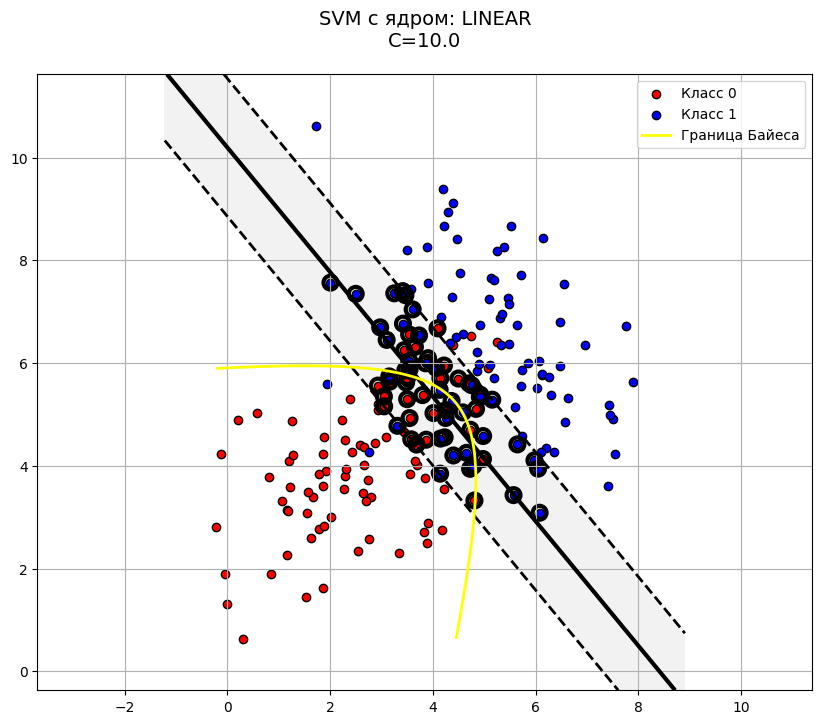


ТЕСТИРУЕМ: POLY_HOMOGENEOUS
QP решение найдено
Успешно построено
Ошибка первого рода: 0.15
Ошибка первого рода: 0.16
Ошибка общая: 0.31
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


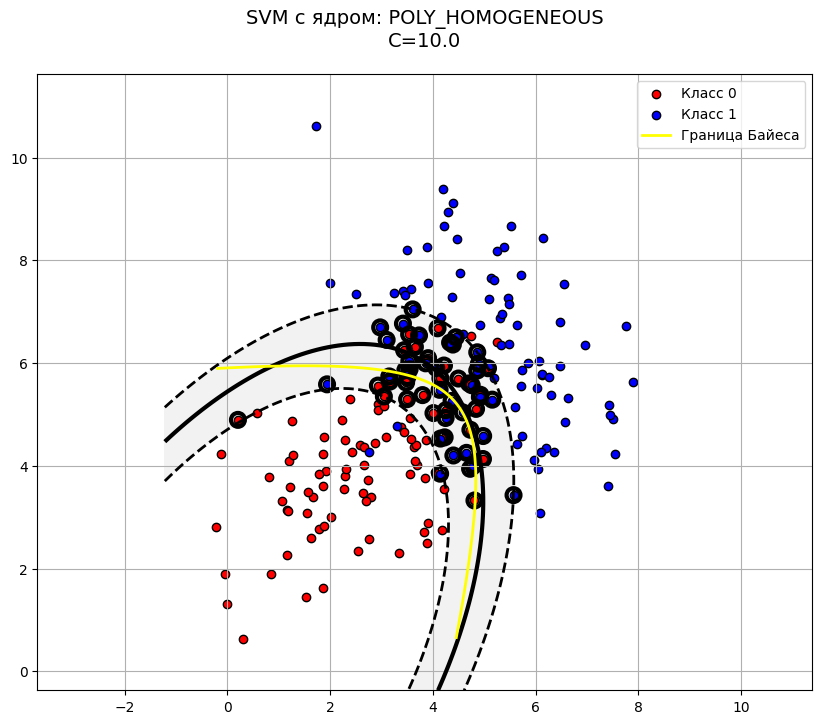


ТЕСТИРУЕМ: POLY_NONHOMOGENEOUS
QP решение найдено
Успешно построено
Ошибка первого рода: 0.17
Ошибка первого рода: 0.14
Ошибка общая: 0.31000000000000005
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


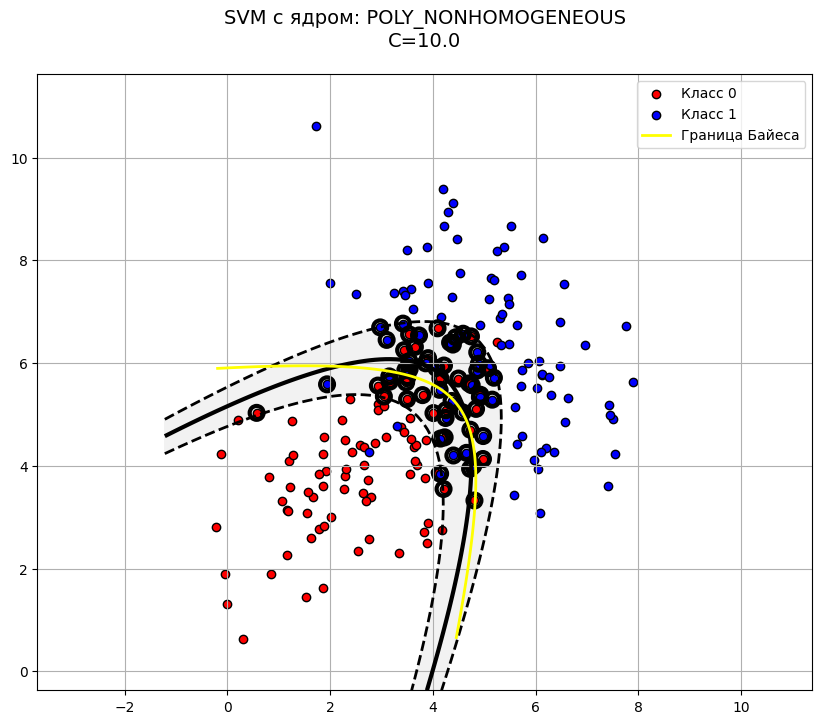


ТЕСТИРУЕМ: RBF
QP решение найдено
Успешно построено
Ошибка первого рода: 0.16
Ошибка первого рода: 0.15
Ошибка общая: 0.31
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


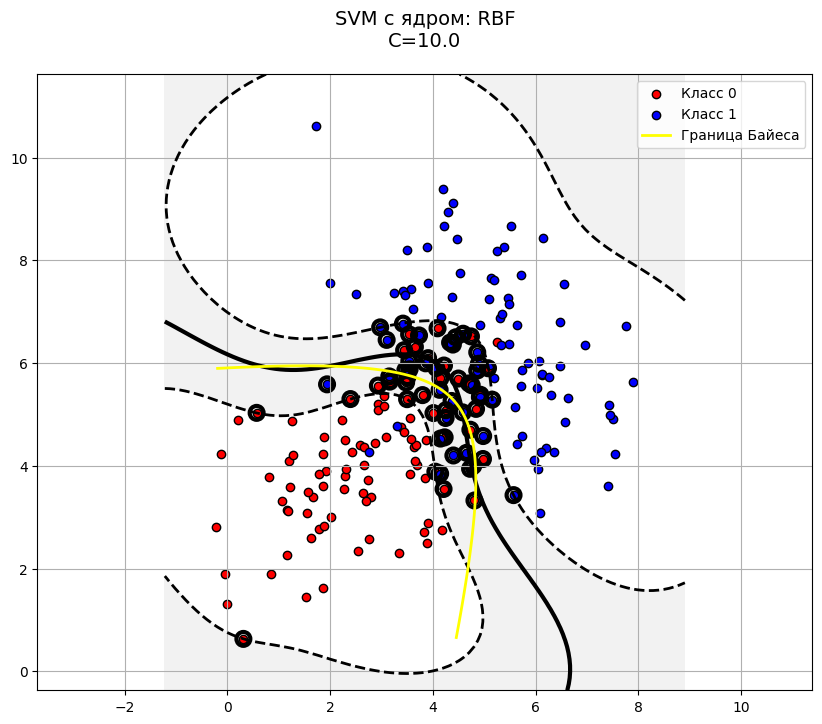


ТЕСТИРУЕМ: GAUSSIAN_RBF
QP решение найдено
Успешно построено
Ошибка первого рода: 0.14
Ошибка первого рода: 0.12
Ошибка общая: 0.26
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


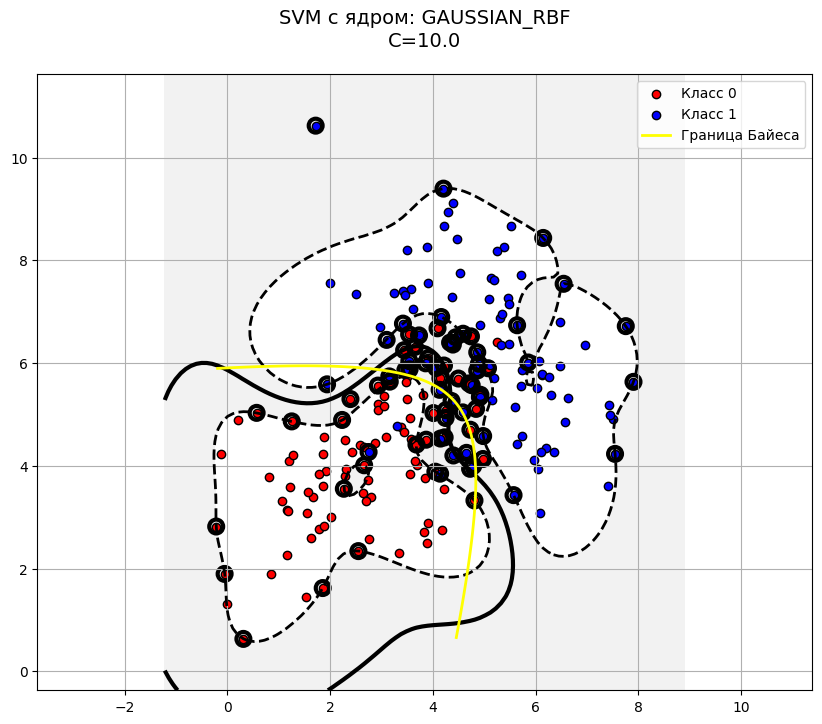


ТЕСТИРУЕМ: SIGMOID
QP решение найдено
Успешно построено
Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


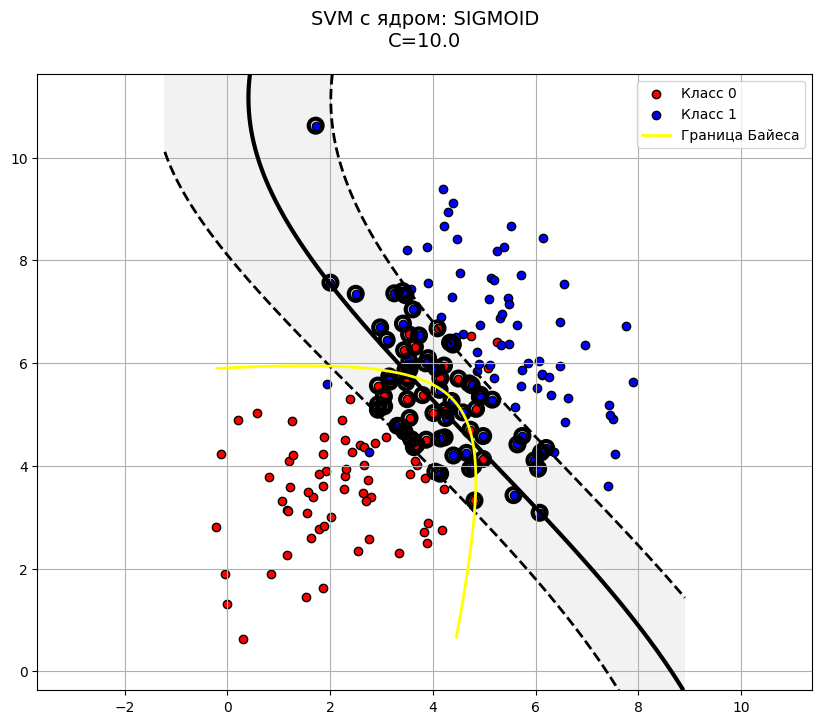

In [72]:
kernel_list = [
    ('linear', {}),
    ('poly_homogeneous', {'degree': 2}),
    ('poly_nonhomogeneous', {'degree': 2}),
    ('rbf', {'gamma': 0.1}),
    ('gaussian_rbf', {'sigma': 1.0}),
    ('sigmoid', {'gamma': 0.01, 'c': -0.5})
]

C = 10.0
results = {}

for kernel_type, kernel_params in kernel_list:
    print(f"\nТЕСТИРУЕМ: {kernel_type.upper()}")
    
    svm_model = build_kernel_svm(X_0, X_1, C, kernel_type, kernel_params)
    
    if svm_model is not None:
        results[kernel_type] = svm_model
        print(f"Успешно построено")
        p01, p10 = calculate_p_errors_with_K(svm_model)
        print(f"Ошибка первого рода: {p01}")
        print(f"Ошибка первого рода: {p10}")
        print(f"Ошибка общая: {p01+p10}")
        p_0_experimental, p_1_experimental, p_total_experimental = experimental_probability_error(X_0, X_1, M0, M1, B0, B1, 0.5, 0.5)
        print(f"Ошибка Байеса первого рода: {p_0_experimental}")
        print(f"Ошибка Байеса первого рода: {p_1_experimental}")
        print(f"Ошибка Байеса общая: {p_total_experimental}")
        visualize_kernel_svm(svm_model)
    else:
        print(f"Не удалось построить модель для {kernel_type}")

In [54]:
def convert_sklearn_to_original_scale(sklearn_model, scaler, kernel_type, kernel_params, C, X_original, r_original):
    support_vectors_original = scaler.inverse_transform(sklearn_model.support_vectors_)
    
    r_converted = np.where(r_original == 0, -1, 1)
    
    return {
        'support_vectors': support_vectors_original,
        'support_labels': r_converted[sklearn_model.support_],
        'support_lambdas': sklearn_model.dual_coef_[0] * r_converted[sklearn_model.support_],
        'lambdas': np.zeros(len(X_original)),
        'w_N': sklearn_model.intercept_[0],
        'kernel_type': kernel_type,
        'kernel_params': kernel_params,
        'C': C,
        'X': X_original,
        'r': r_converted,
        'sklearn_model': sklearn_model,
        'scaler': scaler
    }

In [ ]:
def build_sklearn_svm_models(X_0, X_1, kernel_configs, C=1.0):
    x0 = X_0.T
    x1 = X_1.T
    X = np.vstack([x0, x1])
    r = np.hstack([np.zeros(len(x0)), np.ones(len(x1))])
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    results = {}
    
    for kernel_type, kernel_params in kernel_configs:
        print(f"Обучение sklearn SVM с ядром: {kernel_type}")
        
        if kernel_type == 'linear':
            model = SVC(kernel='linear', C=C)
        elif kernel_type == 'poly_homogeneous':
            # model = SVC(kernel='poly', degree=kernel_params.get('degree', 2), coef0=0, C=C)
            model = SVC(kernel='poly', degree=kernel_params['degree'], coef0=0, C=C)
        elif kernel_type == 'poly_nonhomogeneous':
            # model = SVC(kernel='poly', degree=kernel_params.get('degree', 2), coef0=1, C=C)
            model = SVC(kernel='poly', degree=kernel_params['degree'], coef0=1, C=C)
        elif kernel_type == 'rbf':
            model = SVC(kernel='rbf', gamma=kernel_params.get('gamma', 0.1), C=C)
        elif kernel_type == 'gaussian_rbf':
            sigma = kernel_params.get('sigma', 1.0)
            gamma = 1.0 / (2 * sigma ** 2)
            model = SVC(kernel='rbf', gamma=gamma, C=C)
        elif kernel_type == 'sigmoid':
            model = SVC(kernel='sigmoid', gamma=kernel_params.get('gamma', 0.1), 
                       coef0=kernel_params.get('c', 0), C=C)
        else:
            print(f"Неизвестный тип ядра: {kernel_type}")
            continue
        
        model.fit(X, r)

        svm_model = convert_sklearn_to_original_scale(model, scaler, kernel_type, kernel_params, C, X, r)
        
        results[kernel_type] = svm_model
    
    return results

Обучение sklearn SVM с ядром: linear
Обучение sklearn SVM с ядром: poly_homogeneous
Обучение sklearn SVM с ядром: poly_nonhomogeneous
Обучение sklearn SVM с ядром: rbf
Обучение sklearn SVM с ядром: gaussian_rbf
Обучение sklearn SVM с ядром: sigmoid

ТЕСТИРУЕМ: LINEAR


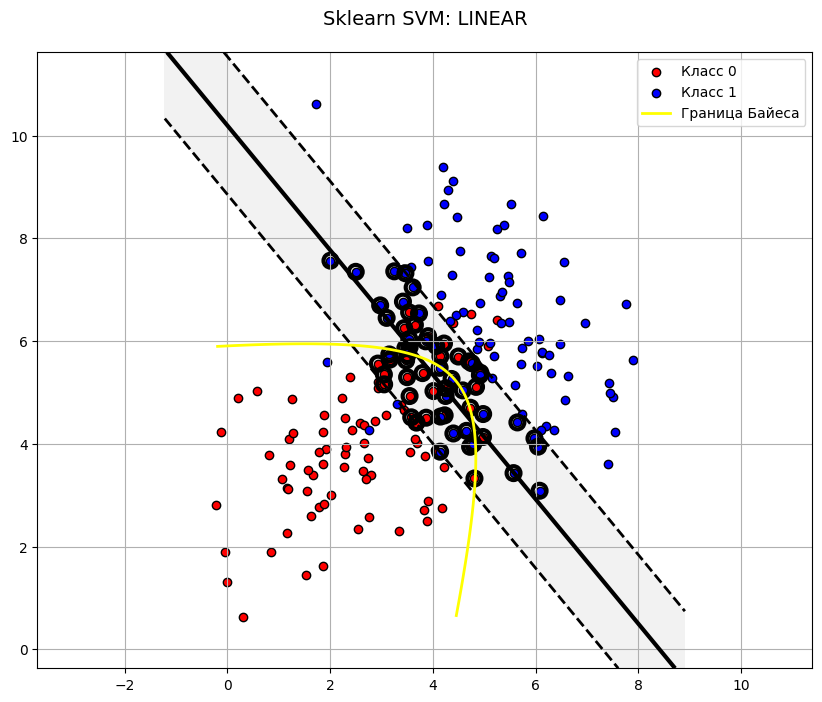

Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005

ТЕСТИРУЕМ: POLY_HOMOGENEOUS


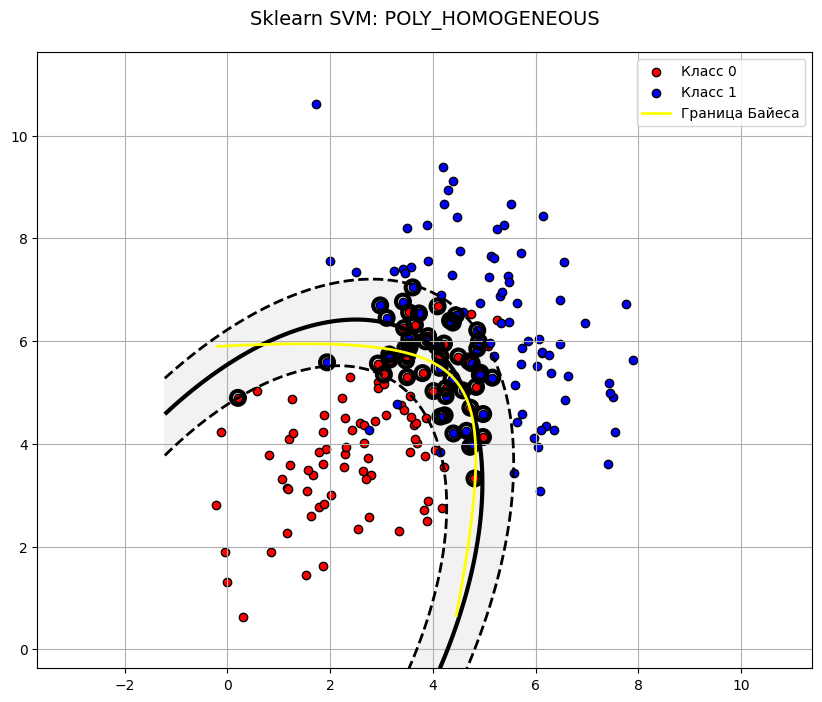

Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005

ТЕСТИРУЕМ: POLY_NONHOMOGENEOUS


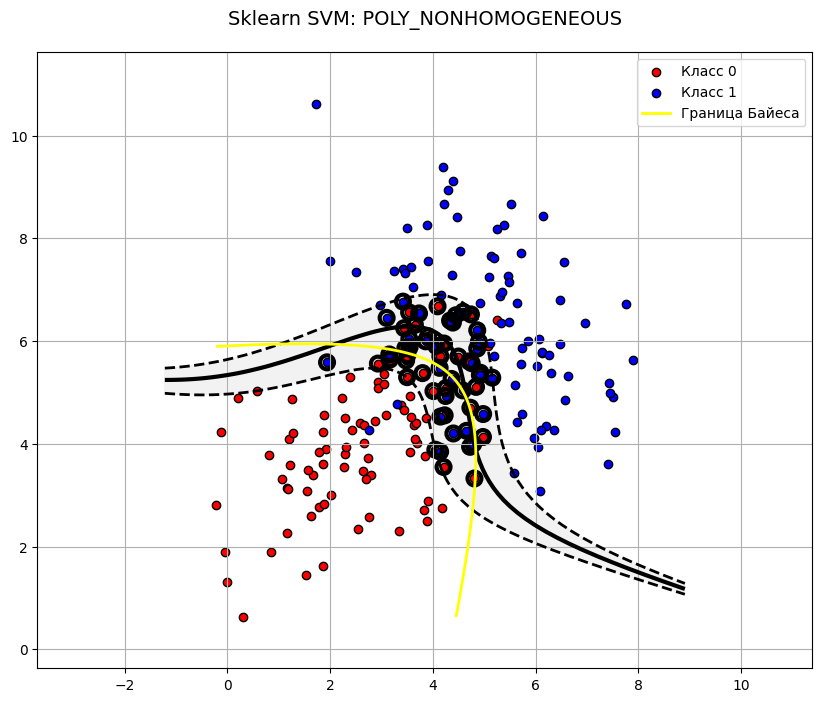

Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005

ТЕСТИРУЕМ: RBF


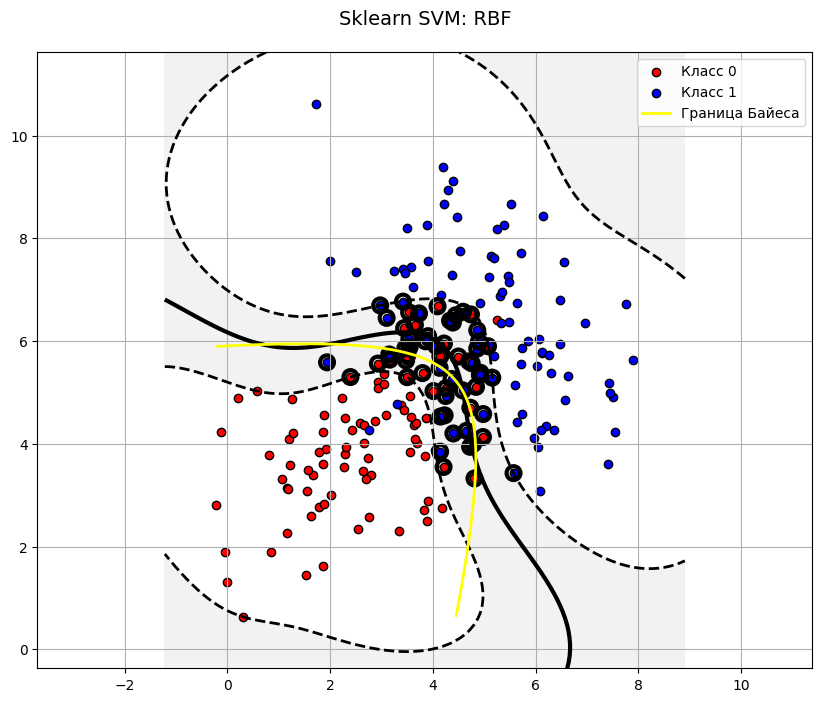

Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005

ТЕСТИРУЕМ: GAUSSIAN_RBF


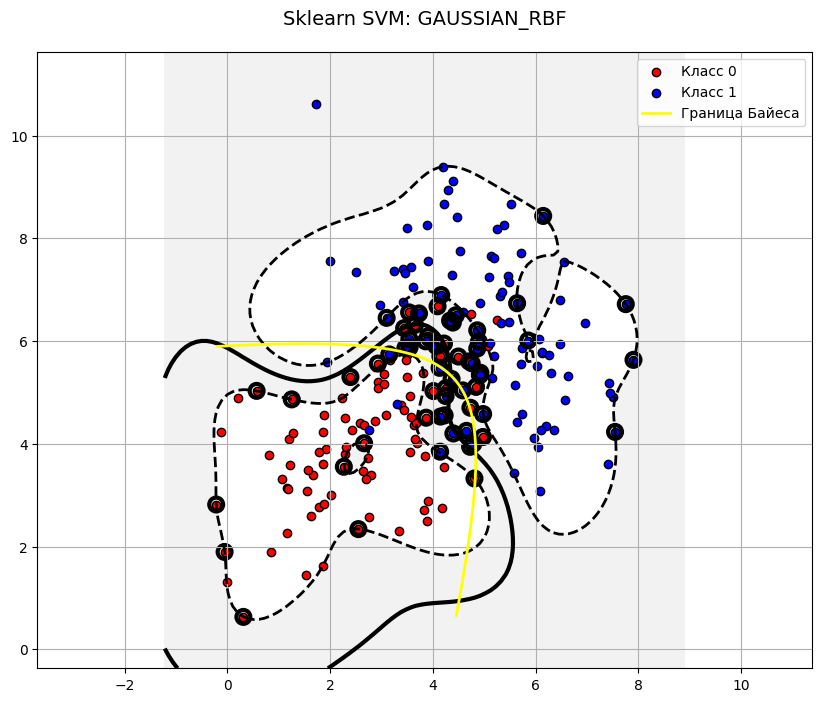

Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005

ТЕСТИРУЕМ: SIGMOID


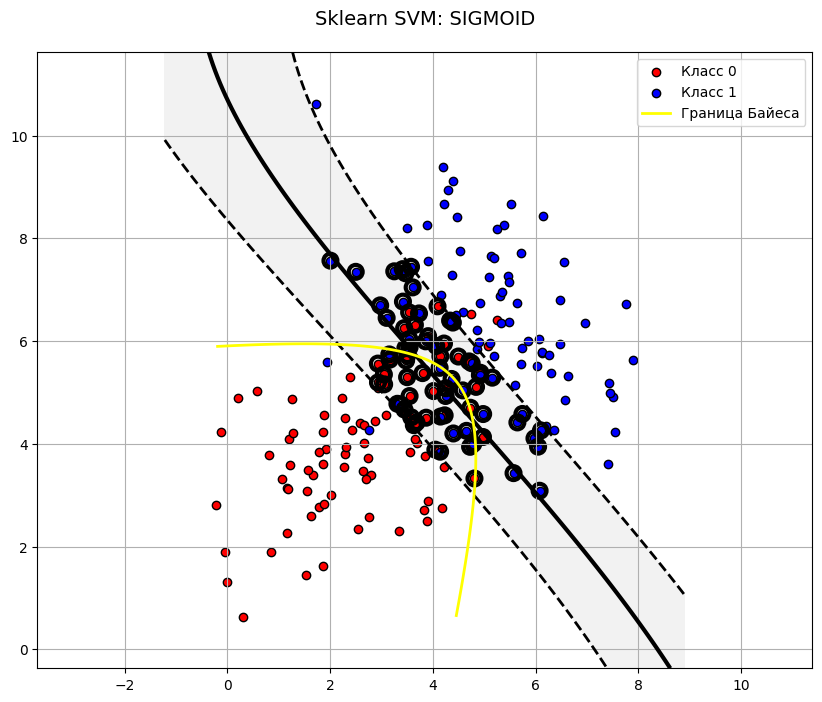

Ошибка первого рода: 0.18
Ошибка первого рода: 0.12
Ошибка общая: 0.3
Ошибка Байеса первого рода: 0.17
Ошибка Байеса первого рода: 0.14
Ошибка Байеса общая: 0.31000000000000005


In [73]:
kernel_list = [
    ('linear', {}),
    ('poly_homogeneous', {'degree': 2}),
    ('poly_nonhomogeneous', {'degree': 3}),
    ('rbf', {'gamma': 0.1}),
    ('gaussian_rbf', {'sigma': 1.0}),
    ('sigmoid', {'gamma': 0.01, 'c': -0.5})
]

sklearn_results = build_sklearn_svm_models(X_0, X_1, kernel_list, C=10.0)

for kernel_type, svm_model in sklearn_results.items():
    print(f"\nТЕСТИРУЕМ: {kernel_type.upper()}")
    visualize_kernel_svm(svm_model, title=f"Sklearn SVM: {kernel_type.upper()}")
    p0, p1 = calculate_p_errors_with_K(svm_model)
    
    print(f"Ошибка первого рода: {p01}")
    print(f"Ошибка первого рода: {p10}")
    print(f"Ошибка общая: {p01+p10}")
    p_0_experimental, p_1_experimental, p_total_experimental = experimental_probability_error(X_0, X_1, M0, M1, B0, B1, 0.5, 0.5)
    print(f"Ошибка Байеса первого рода: {p_0_experimental}")
    print(f"Ошибка Байеса первого рода: {p_1_experimental}")
    print(f"Ошибка Байеса общая: {p_total_experimental}")

    